# 05 — Примеры реалистичных логов для оценки качества текущего вывода

Этот ноутбук не запускает обучение, не импортирует PyTorch/transformers/open_clip
и не подтягивает зависимости. Все блоки ниже — статические примеры того, какие
логи реально можно увидеть при работе текущих скриптов проекта.

Цель: быстро оценить, насколько существующие логи информативны для отладки,
воспроизводимости и анализа экспериментов.

Формат каждого пункта:

- **Где возникает** — модуль/скрипт, который печатает такие строки.
- **Сценарий** — при каком запуске это обычно видно.
- **Пример вывода** — реалистичный stdout или `train.log`.
- **Что можно оценить по логу** — какие качества логирования видны сразу.



## 1. Setup ноутбук: окружение, копирование проекта, sanity-check манифестов

**Где возникает:** `notebooks/00_setup_and_manifests.py`

**Сценарий:** первая ячейка Kaggle-сессии: проверяется CUDA/версии библиотек,
проект копируется из Kaggle Input в `/kaggle/working`, затем проверяются
построенные манифесты.

**Пример вывода:**

```text
torch: 2.6.0+cu126 | cuda: True | cuda ver: 12.6
torchvision: 0.21.0+cu126
transformers: 4.51.3
gpu: Tesla P100-PCIE-16GB | arch list: ['sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']

Copied: /kaggle/input/diploma-claude/Diploma_claude -> /kaggle/working/diploma_claude
['README.md', 'islr', 'notebooks', 'requirements.txt', 'scripts', 'tests']

Manifests built:
  /kaggle/working/manifests/kinetics400_sample/kinetics400_sample_train.csv: 2100 rows, 100 classes
  /kaggle/working/manifests/slovo100/slovo100_train.csv: 16241 rows, 100 classes
  /kaggle/working/manifests/wlasl100/wlasl100_train.csv: 842 rows, 100 classes

Unknown-label check for slovo: ('1001', 'не определ', 'неопредел', 'undefined', 'unknown')
raw matches: 0
label_map matches: 0
```

**Что можно оценить по логу:** хорошо видно окружение и факт копирования кода.
Слабое место: нет явного commit/hash версии проекта, нет полного списка путей
к датасетам и нет предупреждений о том, какие команды построения манифестов
были закомментированы и фактически не выполнялись.



## 2. Подготовка Slovo manifest

**Где возникает:** `scripts/data/prepare_slovo_manifest.py`

**Сценарий:** построение сырого CSV-манифеста по Slovo с учётом train/test,
signer/user_id и begin/end границ жеста.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/prepare_slovo_manifest.py \
    --root /kaggle/input/datasets/<author>/slovo-russian-sign-language-dataset \
    --output /kaggle/working/manifests/slovo_raw.csv

Slovo: 19987 rows (16008 train, 3979 test), 1000 classes, 123 missing video files
```

**Что можно оценить по логу:** видны размеры и число пропущенных видео.
Слабое место: не видно примеров missing-файлов, распределения классов,
количества пустых `begin/end`, числа пользователей и статистики по split.



## 3. Подготовка WLASL manifest

**Где возникает:** `scripts/data/prepare_wlasl_manifest.py`

**Сценарий:** сбор WLASL из `WLASL_v0.3.json` и папки `videos/`; опционально
фильтрация через NSLT JSON.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/prepare_wlasl_manifest.py \
    --root /kaggle/input/datasets/risangbaskoro/wlasl-processed \
    --output /kaggle/working/manifests/wlasl_raw.csv \
    --nslt-file /kaggle/input/nslt-json/nslt_100.json

WLASL: 1913 rows, 100 glosses, 48 missing video files, filtered by NSLT to 2038 video_ids (77 excluded)
```

**Что можно оценить по логу:** понятно, сколько строк, классов и missing video.
Слабое место: нет разбивки по train/val/test, нет списка исключённых `video_id`,
нет предупреждения, если после фильтрации какой-то gloss почти исчез.



## 4. Подготовка AUTSL manifest

**Где возникает:** `scripts/data/prepare_autsl_manifest.py`

**Сценарий:** попытка собрать AUTSL из train/val/test папок и label CSV.
Этот скрипт не входит в основной Kaggle-пайплайн, но логирование в нём есть.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/prepare_autsl_manifest.py \
    --root /kaggle/input/autsl \
    --output /kaggle/working/manifests/autsl_raw.csv

  skip val: missing /kaggle/input/autsl/val_labels.csv or /kaggle/input/autsl/val
AUTSL: 27543 rows, 226 classes, 381 missing videos
```

**Что можно оценить по логу:** видно, что split был пропущен, и итоговый размер.
Слабое место: нет критичности пропуска split, нет примеров missing filenames.



## 5. Подготовка Kinetics manifest

**Где возникает:** `scripts/data/prepare_kinetics_folder_manifest.py`

**Сценарий:** сбор Kinetics-подвыборки из структуры `train/<class>/<video>`.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/prepare_kinetics_folder_manifest.py \
    --root /kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini \
    --output /kaggle/working/manifests/kinetics_raw.csv

  skip missing split: /kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini/val
  skip missing split: /kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini/test
Kinetics: 18342 rows across 400 classes
```

**Что можно оценить по логу:** видны отсутствующие split и итоговый объём.
Слабое место: нет распределения по классам и нет явного пояснения, что дальше
`build_sampled_manifest.py` создаст train/val/test случайным split.



## 6. Сэмплирование 100-классового manifest

**Где возникает:** `scripts/data/build_sampled_manifest.py`

**Сценарий:** создание `slovo100`, `wlasl100` или `kinetics400_sample`.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/build_sampled_manifest.py \
    --input /kaggle/working/manifests/slovo_raw.csv \
    --output-dir /kaggle/working/manifests/slovo100 \
    --dataset-name slovo100 \
    --num-classes 100 \
    --samples-per-class 0 \
    --split-mode signer_independent \
    --val-signers 1 \
    --test-signers 1 \
    --seed 42

train: 15784
val: 231
test: 226
classes: 100
```

**Что можно оценить по логу:** очень коротко видны размеры split и число классов.
Слабое место: нет списка выбранных классов, seed виден только в команде, нет
числа signers в split и нет проверки, что каждый класс попал в train/val/test.



## 7. Few-shot splits для SignVLM F2

**Где возникает:** `scripts/data/make_fewshot_splits.py`

**Сценарий:** создание k-shot train CSV для `k = 1, 2, 4, 8` и разных seed.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/data/make_fewshot_splits.py \
    --train /kaggle/working/manifests/slovo100/slovo100_train.csv \
    --test /kaggle/working/manifests/slovo100/slovo100_test.csv \
    --output-dir /kaggle/working/manifests/slovo100_fewshot \
    --shots 1 2 4 8 \
    --seeds 42 43 44

shot1_seed42: train=100 test=226
shot2_seed42: train=200 test=226
shot4_seed42: train=400 test=226
shot8_seed42: train=800 test=226
shot1_seed43: train=100 test=226
shot2_seed43: train=200 test=226
shot4_seed43: train=400 test=226
shot8_seed43: train=800 test=226
shot1_seed44: train=100 test=226
shot2_seed44: train=200 test=226
shot4_seed44: train=400 test=226
shot8_seed44: train=800 test=226
```

**Что можно оценить по логу:** видно, что размеры соответствуют k-shot схеме.
Слабое место: нет информации, какие классы имели меньше `k` примеров, нет
проверки пересечения train/test и нет статистики по пользователям.



## 8. Основной train.py: обычный успешный запуск A00

**Где возникает:** `scripts/train.py` + `islr/training.py`

**Сценарий:** запуск полного пайплайна `A00_full_pipeline` с VideoMAE,
Kinetics-pretrained, augmentations, IoU-balanced CE, boundary head.

**Пример stdout ноутбука/консоли:**

```text
$ python /kaggle/working/diploma_claude/scripts/train.py \
    --train-csv /kaggle/working/manifests/slovo100/slovo100_train.csv \
    --val-csv /kaggle/working/manifests/slovo100/slovo100_val.csv \
    --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv \
    --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv \
    --output-dir /kaggle/working/work_dirs \
    --experiment-id A00_full_pipeline \
    --append-results-to /kaggle/working/results/all_results.csv \
    --skip-if-done \
    --model videomae \
    --pretrained k400

Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
num_classes = 100
Building model: videomae (pretrained=k400, boundary_head=True)
Logging training to /kaggle/working/work_dirs/A00_full_pipeline/train.log
  [epoch 000] step 0000 | loss 5.0824 | lr 3.33e-05
  [epoch 000] step 0020 | loss 4.8719 | lr 3.33e-05
  [epoch 000] step 0040 | loss 4.6941 | lr 3.33e-05
  [epoch 000] step 0060 | loss 4.5327 | lr 3.33e-05
  [epoch 000] step 0080 | loss 4.4213 | lr 3.33e-05
epoch 000 | loss 4.6175 | val top1 0.0487 top5 0.1883 f1 0.0319 | 752s
  [epoch 001] step 0000 | loss 4.2819 | lr 6.67e-05
  [epoch 001] step 0020 | loss 4.1026 | lr 6.67e-05
  [epoch 001] step 0040 | loss 3.9947 | lr 6.67e-05
  [epoch 001] step 0060 | loss 3.8432 | lr 6.67e-05
  [epoch 001] step 0080 | loss 3.7618 | lr 6.67e-05
epoch 001 | loss 3.9551 | val top1 0.1186 top5 0.3542 f1 0.0874 | 1508s
  [epoch 002] step 0000 | loss 3.5128 | lr 1.00e-04
  [epoch 002] step 0020 | loss 3.4680 | lr 1.00e-04
  [epoch 002] step 0040 | loss 3.3304 | lr 1.00e-04
  [epoch 002] step 0060 | loss 3.2292 | lr 1.00e-04
  [epoch 002] step 0080 | loss 3.1165 | lr 1.00e-04
epoch 002 | loss 3.3037 | val top1 0.2119 top5 0.5127 f1 0.1635 | 2261s
  [epoch 003] step 0000 | loss 2.9746 | lr 1.00e-04
  [epoch 003] step 0020 | loss 2.8361 | lr 1.00e-04
  [epoch 003] step 0040 | loss 2.9188 | lr 1.00e-04
  [epoch 003] step 0060 | loss 2.7813 | lr 1.00e-04
  [epoch 003] step 0080 | loss 2.6420 | lr 1.00e-04
epoch 003 | loss 2.8412 | val top1 0.3263 top5 0.6653 f1 0.2748 | 3019s
  [epoch 004] step 0000 | loss 2.5261 | lr 9.96e-05
  [epoch 004] step 0020 | loss 2.4980 | lr 9.96e-05
  [epoch 004] step 0040 | loss 2.3184 | lr 9.96e-05
  [epoch 004] step 0060 | loss 2.4372 | lr 9.96e-05
  [epoch 004] step 0080 | loss 2.2961 | lr 9.96e-05
epoch 004 | loss 2.4217 | val top1 0.4195 top5 0.7585 f1 0.3670 | 3775s
...
epoch 017 | loss 0.9248 | val top1 0.7331 top5 0.9619 f1 0.7026 | 13581s
epoch 018 | loss 0.8984 | val top1 0.7288 top5 0.9661 f1 0.6993 | 14336s
epoch 019 | loss 0.8899 | val top1 0.7415 top5 0.9703 f1 0.7148 | 15093s
epoch 020 | loss 0.8625 | val top1 0.7394 top5 0.9661 f1 0.7110 | 15848s
TEST | top1 0.7124 top5 0.9558 f1 0.6897
Appended result row for A00_full_pipeline -> /kaggle/working/results/all_results.csv
DONE A00_full_pipeline: best top1=0.7415
```

**Пример содержимого `work_dirs/A00_full_pipeline/train.log`:**

```text
Logging training to /kaggle/working/work_dirs/A00_full_pipeline/train.log
  [epoch 000] step 0000 | loss 5.0824 | lr 3.33e-05
  [epoch 000] step 0020 | loss 4.8719 | lr 3.33e-05
  [epoch 000] step 0040 | loss 4.6941 | lr 3.33e-05
  [epoch 000] step 0060 | loss 4.5327 | lr 3.33e-05
  [epoch 000] step 0080 | loss 4.4213 | lr 3.33e-05
epoch 000 | loss 4.6175 | val top1 0.0487 top5 0.1883 f1 0.0319 | 752s
epoch 001 | loss 3.9551 | val top1 0.1186 top5 0.3542 f1 0.0874 | 1508s
epoch 002 | loss 3.3037 | val top1 0.2119 top5 0.5127 f1 0.1635 | 2261s
epoch 003 | loss 2.8412 | val top1 0.3263 top5 0.6653 f1 0.2748 | 3019s
epoch 004 | loss 2.4217 | val top1 0.4195 top5 0.7585 f1 0.3670 | 3775s
epoch 005 | loss 2.0916 | val top1 0.5127 top5 0.8347 f1 0.4616 | 4531s
epoch 006 | loss 1.8213 | val top1 0.5678 top5 0.8856 f1 0.5198 | 5288s
epoch 007 | loss 1.5970 | val top1 0.6186 top5 0.9195 f1 0.5783 | 6041s
epoch 008 | loss 1.4382 | val top1 0.6525 top5 0.9364 f1 0.6189 | 6798s
epoch 009 | loss 1.3147 | val top1 0.6822 top5 0.9449 f1 0.6490 | 7554s
epoch 010 | loss 1.2093 | val top1 0.6949 top5 0.9534 f1 0.6652 | 8310s
epoch 011 | loss 1.1238 | val top1 0.7076 top5 0.9534 f1 0.6759 | 9065s
epoch 012 | loss 1.0664 | val top1 0.7186 top5 0.9576 f1 0.6894 | 9822s
epoch 013 | loss 1.0201 | val top1 0.7246 top5 0.9619 f1 0.6955 | 10578s
epoch 014 | loss 0.9833 | val top1 0.7288 top5 0.9576 f1 0.6988 | 11334s
epoch 015 | loss 0.9556 | val top1 0.7331 top5 0.9619 f1 0.7041 | 12091s
epoch 016 | loss 0.9397 | val top1 0.7331 top5 0.9619 f1 0.7037 | 12836s
epoch 017 | loss 0.9248 | val top1 0.7331 top5 0.9619 f1 0.7026 | 13581s
epoch 018 | loss 0.8984 | val top1 0.7288 top5 0.9661 f1 0.6993 | 14336s
epoch 019 | loss 0.8899 | val top1 0.7415 top5 0.9703 f1 0.7148 | 15093s
epoch 020 | loss 0.8625 | val top1 0.7394 top5 0.9661 f1 0.7110 | 15848s
TEST | top1 0.7124 top5 0.9558 f1 0.6897
```

**Что можно оценить по логу:** текущий лог хорошо показывает динамику loss,
lr, validation metrics, elapsed time и финальный test. Слабое место: в
`train.log` не пишутся аргументы запуска, seed, размер train/val/test,
batch size, clip_len, augmentation flags, количество параметров, имя GPU,
путь к checkpoint и причина сохранения нового best.



## 9. Основной train.py: early stopping

**Где возникает:** `islr/training.py`

**Сценарий:** качество перестало расти на `min_delta=0.003`, patience закончился.

**Пример вывода:**

```text
Logging training to /kaggle/working/work_dirs/A11_no_iou_loss/train.log
epoch 000 | loss 4.3901 | val top1 0.0932 top5 0.3136 f1 0.0604 | 719s
epoch 001 | loss 3.7054 | val top1 0.2013 top5 0.5042 f1 0.1479 | 1438s
epoch 002 | loss 3.1027 | val top1 0.3199 top5 0.6525 f1 0.2628 | 2156s
epoch 003 | loss 2.6392 | val top1 0.4068 top5 0.7542 f1 0.3531 | 2874s
epoch 004 | loss 2.2821 | val top1 0.4873 top5 0.8051 f1 0.4317 | 3593s
epoch 005 | loss 2.0418 | val top1 0.5233 top5 0.8432 f1 0.4692 | 4311s
epoch 006 | loss 1.8440 | val top1 0.5360 top5 0.8559 f1 0.4851 | 5028s
epoch 007 | loss 1.7024 | val top1 0.5381 top5 0.8517 f1 0.4869 | 5746s
epoch 008 | loss 1.5880 | val top1 0.5403 top5 0.8602 f1 0.4914 | 6463s
epoch 009 | loss 1.5046 | val top1 0.5381 top5 0.8644 f1 0.4898 | 7181s
epoch 010 | loss 1.4329 | val top1 0.5424 top5 0.8644 f1 0.4930 | 7898s
epoch 011 | loss 1.3815 | val top1 0.5403 top5 0.8602 f1 0.4910 | 8616s
epoch 012 | loss 1.3337 | val top1 0.5458 top5 0.8644 f1 0.4907 | 9334s
Early stop at epoch 12 (best top1=0.5424 @ epoch 10)
TEST | top1 0.5155 top5 0.8496 f1 0.4691
```

**Что можно оценить по логу:** early stopping читается понятно. Слабое место:
не видно `patience_left`, `min_delta`, и не видно, на каких эпохах сохранялся
новый `best.pt`.



## 10. train.py: загрузка checkpoint и несовпадение ключей

**Где возникает:** `scripts/train.py` + `islr/utils.py`

**Сценарий:** cross-lingual или K2-chain: загружаем `best.pt` от другого
эксперимента, classifier/boundary head могут частично не совпасть.

**Пример вывода:**

```text
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
num_classes = 100
Building model: videomae (pretrained=k400, boundary_head=True)
Loading weights from /kaggle/working/work_dirs/C1_wlasl_then_slovo_step1/best.pt
  load_checkpoint: missing keys (first 5): ['classifier.weight', 'classifier.bias']
  load_checkpoint: unexpected keys (first 5): ['head.weight', 'head.bias']
Logging training to /kaggle/working/work_dirs/C1_wlasl_then_slovo/train.log
epoch 000 | loss 2.9872 | val top1 0.2733 top5 0.6017 f1 0.2208 | 741s
epoch 001 | loss 2.4016 | val top1 0.4216 top5 0.7627 f1 0.3725 | 1485s
epoch 002 | loss 2.0083 | val top1 0.5233 top5 0.8432 f1 0.4740 | 2228s
...
TEST | top1 0.5863 top5 0.8982 f1 0.5481
Appended result row for C1_wlasl_then_slovo -> /kaggle/working/results/all_results.csv
DONE C1_wlasl_then_slovo: best top1=0.6250
```

**Что можно оценить по логу:** видно, что checkpoint был загружен не строго.
Слабое место: не видно, сколько всего keys missing/unexpected, нет объяснения,
ожидалось ли это для данного сценария.



## 11. train.py: пропуск уже готового эксперимента

**Где возникает:** `scripts/train.py`

**Сценарий:** notebook перезапущен, а `<exp_id>.done` уже существует.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/train.py ... \
    --experiment-id A00_full_pipeline \
    --skip-if-done

SKIP A00_full_pipeline: done flag present in /kaggle/working/work_dirs/A00_full_pipeline
```

**Что можно оценить по логу:** понятно, почему эксперимент не стартовал.
Слабое место: не видно, какие метрики уже есть у пропущенного эксперимента.



## 12. train.py: финальная запись в results/all_results.csv

**Где возникает:** `scripts/train.py`, функция `append_result`

**Сценарий:** после успешного обучения метрики добавляются/обновляются в
master CSV.

**Пример вывода:**

```text
TEST | top1 0.7124 top5 0.9558 f1 0.6897
Appended result row for A00_full_pipeline -> /kaggle/working/results/all_results.csv
DONE A00_full_pipeline: best top1=0.7415
```

**Что можно оценить по логу:** видно, что результат записан. Слабое место:
stdout не показывает полную записанную строку CSV: model, pretraining,
augmentations, losses, test_top1, epoch, train_time_sec.



## 13. Notebook 01: запуск ablation и Kinetics-сценариев

**Где возникает:** `notebooks/01_run_ablation_and_kinetics.py`

**Сценарий:** notebook последовательно вызывает `scripts/train.py` для A00,
A01-A12, K0, K2a и K2.

**Пример вывода:**

```text
Restored from /kaggle/input/diploma-results

$ python /kaggle/working/diploma_claude/scripts/train.py --train-csv /kaggle/working/manifests/slovo100/slovo100_train.csv --val-csv /kaggle/working/manifests/slovo100/slovo100_val.csv --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id A00_full_pipeline --append-results-to /kaggle/working/results/all_results.csv --skip-if-done --model videomae --pretrained k400
SKIP A00_full_pipeline: done flag present in /kaggle/working/work_dirs/A00_full_pipeline

$ python /kaggle/working/diploma_claude/scripts/train.py --train-csv /kaggle/working/manifests/slovo100/slovo100_train.csv --val-csv /kaggle/working/manifests/slovo100/slovo100_val.csv --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id A01_no_image_augs --append-results-to /kaggle/working/results/all_results.csv --skip-if-done --model videomae --pretrained k400 --no-aug-image
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
num_classes = 100
Building model: videomae (pretrained=k400, boundary_head=True)
Logging training to /kaggle/working/work_dirs/A01_no_image_augs/train.log
epoch 000 | loss 4.7118 | val top1 0.0403 top5 0.1695 f1 0.0288 | 746s
epoch 001 | loss 4.0452 | val top1 0.1038 top5 0.3305 f1 0.0762 | 1493s
...
TEST | top1 0.6814 top5 0.9469 f1 0.6520
Appended result row for A01_no_image_augs -> /kaggle/working/results/all_results.csv
DONE A01_no_image_augs: best top1=0.7182

K2a checkpoint not found — skipping K2
```

**Что можно оценить по логу:** команды запуска видны полностью, что помогает
воспроизвести эксперимент. Слабое место: notebook не агрегирует итоговую
таблицу сразу после каждого блока и не пишет статус-табло по всем запланированным
экспериментам.



## 14. Notebook 02: cross-lingual transfer C1-C3

**Где возникает:** `notebooks/02_run_crosslingual.py`

**Сценарий:** сначала обучение на WLASL, затем fine-tune на Slovo из `best.pt`.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/train.py --train-csv /kaggle/working/manifests/wlasl100/wlasl100_train.csv --val-csv /kaggle/working/manifests/wlasl100/wlasl100_val.csv --test-csv /kaggle/working/manifests/wlasl100/wlasl100_test.csv --label-map /kaggle/working/manifests/wlasl100/wlasl100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id C1_wlasl_then_slovo_step1 --append-results-to /kaggle/working/results/all_results.csv --skip-if-done --model videomae --pretrained k400 --num-layers 12 --epochs 15
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
num_classes = 100
Building model: videomae (pretrained=k400, boundary_head=True)
Logging training to /kaggle/working/work_dirs/C1_wlasl_then_slovo_step1/train.log
epoch 000 | loss 4.9120 | val top1 0.0617 top5 0.2340 f1 0.0421 | 114s
epoch 001 | loss 4.2806 | val top1 0.1489 top5 0.3617 f1 0.1078 | 226s
...
TEST | top1 0.2971 top5 0.6184 f1 0.2616
Appended result row for C1_wlasl_then_slovo_step1 -> /kaggle/working/results/all_results.csv
DONE C1_wlasl_then_slovo_step1: best top1=0.3404

$ python /kaggle/working/diploma_claude/scripts/train.py --train-csv /kaggle/working/manifests/slovo100/slovo100_train.csv --val-csv /kaggle/working/manifests/slovo100/slovo100_val.csv --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id C1_wlasl_then_slovo --append-results-to /kaggle/working/results/all_results.csv --skip-if-done --model videomae --pretrained k400 --num-layers 12 --load-from /kaggle/working/work_dirs/C1_wlasl_then_slovo_step1/best.pt --epochs 30
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
num_classes = 100
Building model: videomae (pretrained=k400, boundary_head=True)
Loading weights from /kaggle/working/work_dirs/C1_wlasl_then_slovo_step1/best.pt
Logging training to /kaggle/working/work_dirs/C1_wlasl_then_slovo/train.log
epoch 000 | loss 2.9744 | val top1 0.2788 top5 0.6102 f1 0.2263 | 744s
...
DONE C1_wlasl_then_slovo: best top1=0.6250
```

**Пример ошибки цепочки:**

```text
  step1 best.pt missing for C3_wlasl_mvit_then_slovo_step1 — cannot run step2
```

**Что можно оценить по логу:** хорошо видно разделение step1/step2. Слабое
место: не видно, почему `best.pt` отсутствует: падение, early stop без best,
OOM, прерывание сессии или неправильный путь.



## 15. SignVLM zero-shot F0

**Где возникает:** `notebooks/03_run_signvlm.py` + `scripts/train_signvlm.py`

**Сценарий:** запуск `--mode zero_shot`, без обучения и без `train.log`.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/train_signvlm.py --mode zero_shot --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id F0_siglip2_zeroshot --prompt жест {label} --append-results-to /kaggle/working/results/all_results.csv --skip-if-done

Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
Appended SignVLM row for F0_siglip2_zeroshot
DONE F0_siglip2_zeroshot: top1=0.0310
```

**Что можно оценить по логу:** видно только итог. Слабое место: для zero-shot
почти нет диагностической информации: не печатается backbone, encoder model,
prompt, batch size, число классов, число test samples, top5, macro_f1 и время.



## 16. SignVLM supervised F3

**Где возникает:** `scripts/train_signvlm.py`

**Сценарий:** frozen SigLIP2/CLIP encoder + trainable temporal decoder.

**Пример stdout и `train.log`:**

```text
$ python /kaggle/working/diploma_claude/scripts/train_signvlm.py \
    --mode train \
    --train-csv /kaggle/working/manifests/slovo100/slovo100_train.csv \
    --test-csv /kaggle/working/manifests/slovo100/slovo100_test.csv \
    --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv \
    --output-dir /kaggle/working/work_dirs \
    --experiment-id F3_siglip2_full_supervised \
    --epochs 30 \
    --append-results-to /kaggle/working/results/all_results.csv \
    --skip-if-done

Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
Logging training to /kaggle/working/work_dirs/F3_siglip2_full_supervised/train.log
epoch 000 | loss 4.5812 | test top1 0.0398
epoch 001 | loss 4.3105 | test top1 0.0619
epoch 002 | loss 4.0674 | test top1 0.0885
epoch 003 | loss 3.7810 | test top1 0.1283
epoch 004 | loss 3.5227 | test top1 0.1770
epoch 005 | loss 3.2609 | test top1 0.2257
epoch 006 | loss 3.0142 | test top1 0.2699
epoch 007 | loss 2.8294 | test top1 0.3053
epoch 008 | loss 2.6528 | test top1 0.3407
epoch 009 | loss 2.4876 | test top1 0.3761
epoch 010 | loss 2.3614 | test top1 0.3982
epoch 011 | loss 2.2441 | test top1 0.4115
epoch 012 | loss 2.1480 | test top1 0.4248
epoch 013 | loss 2.0712 | test top1 0.4248
epoch 014 | loss 1.9987 | test top1 0.4336
epoch 015 | loss 1.9429 | test top1 0.4292
epoch 016 | loss 1.8975 | test top1 0.4381
epoch 017 | loss 1.8546 | test top1 0.4381
epoch 018 | loss 1.8210 | test top1 0.4381
epoch 019 | loss 1.7924 | test top1 0.4336
epoch 020 | loss 1.7702 | test top1 0.4292
Early stop at epoch 20 (best top1=0.4381 @ epoch 16)
Appended SignVLM row for F3_siglip2_full_supervised
DONE F3_siglip2_full_supervised: top1=0.4381
```

**Что можно оценить по логу:** видна learning curve. Слабое место: логируется
только `test top1`, без top5/macro_f1 по эпохам, без lr, без времени эпохи,
без количества trainable parameters и без признака, что encoder frozen.



## 17. SignVLM F2 few-shot batch

**Где возникает:** `notebooks/03_run_signvlm.py`

**Сценарий:** цикл по seeds и shots запускает много маленьких экспериментов.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/train_signvlm.py --mode train --train-csv /kaggle/working/manifests/slovo100_fewshot/shot1_seed42_train.csv --test-csv /kaggle/working/manifests/slovo100_fewshot/shot1_seed42_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id F2_siglip2_shot1_seed42 --epochs 20 --patience 4 --seed 42 --append-results-to /kaggle/working/results/all_results.csv --skip-if-done
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
Logging training to /kaggle/working/work_dirs/F2_siglip2_shot1_seed42/train.log
epoch 000 | loss 4.7208 | test top1 0.0133
epoch 001 | loss 4.5591 | test top1 0.0177
epoch 002 | loss 4.4037 | test top1 0.0265
epoch 003 | loss 4.2602 | test top1 0.0265
epoch 004 | loss 4.1219 | test top1 0.0354
epoch 005 | loss 4.0048 | test top1 0.0310
epoch 006 | loss 3.8822 | test top1 0.0398
epoch 007 | loss 3.7905 | test top1 0.0354
epoch 008 | loss 3.7021 | test top1 0.0354
epoch 009 | loss 3.6214 | test top1 0.0310
epoch 010 | loss 3.5480 | test top1 0.0310
Early stop at epoch 10 (best top1=0.0398 @ epoch 6)
Appended SignVLM row for F2_siglip2_shot1_seed42
DONE F2_siglip2_shot1_seed42: top1=0.0398

$ python /kaggle/working/diploma_claude/scripts/train_signvlm.py --mode train --train-csv /kaggle/working/manifests/slovo100_fewshot/shot8_seed42_train.csv --test-csv /kaggle/working/manifests/slovo100_fewshot/shot8_seed42_test.csv --label-map /kaggle/working/manifests/slovo100/slovo100_label_map.csv --output-dir /kaggle/working/work_dirs --experiment-id F2_siglip2_shot8_seed42 --epochs 20 --patience 4 --seed 42 --append-results-to /kaggle/working/results/all_results.csv --skip-if-done
Env: {'python': 'Python 3.12.3', 'torch': '2.6.0+cu126', 'cuda': '12.6', 'device': 'cuda'}
Logging training to /kaggle/working/work_dirs/F2_siglip2_shot8_seed42/train.log
epoch 000 | loss 4.6127 | test top1 0.0354
epoch 001 | loss 4.2488 | test top1 0.0575
epoch 002 | loss 3.9049 | test top1 0.1018
epoch 003 | loss 3.5972 | test top1 0.1460
epoch 004 | loss 3.3243 | test top1 0.1858
epoch 005 | loss 3.0795 | test top1 0.2257
epoch 006 | loss 2.8834 | test top1 0.2522
epoch 007 | loss 2.7041 | test top1 0.2788
epoch 008 | loss 2.5486 | test top1 0.2876
epoch 009 | loss 2.4180 | test top1 0.3009
...
DONE F2_siglip2_shot8_seed42: top1=0.3230
```

**Что можно оценить по логу:** удобно сравнивать shot1 vs shot8 по top1.
Слабое место: нет summary-таблицы по всем seed/shot прямо в этом ноутбуке.



## 18. Aggregation: сбор metrics.json в summary CSV

**Где возникает:** `scripts/aggregate_results.py`

**Сценарий:** notebook 04 собирает все `metrics.json` из `work_dirs`.

**Пример вывода:**

```text
$ python /kaggle/working/diploma_claude/scripts/aggregate_results.py \
    --inputs /kaggle/working/work_dirs \
    --master-csv /kaggle/working/results/all_results.csv \
    --output /kaggle/working/results/all_summary.csv

Wrote 31 rows to /kaggle/working/results/all_summary.csv
```

**Что можно оценить по логу:** видно количество строк и путь. Слабое место:
не видно, какие эксперименты были найдены только в `metrics.json`, какие только
в master CSV, были ли дубликаты или пропущенные поля.



## 19. Results notebook: ablation table

**Где возникает:** `notebooks/04_results.py`

**Сценарий:** печать таблицы A-блока после агрегации.

**Пример вывода:**

```text
experiment_id         top1       test_top1    delta_vs_A00
A00_full_pipeline     0.7515     0.7124        0.0000
A01_no_image_augs     0.7182     0.6814       -0.0233
A02_no_mixup_cutmix   0.6949     0.6681       -0.0466
A03_no_video_augs     0.6720     0.6416       -0.0695
A04_no_boundary_shift 0.7246     0.6903       -0.0169
A09_no_boundary_head  0.6811     0.6504       -0.0604
A11_no_iou_loss       0.5424     0.5155       -0.1991
A12_plain_ce          0.5019     0.4867       -0.2396
```

**Что можно оценить по логу:** таблица хороша для быстрой оценки ablation.
Слабое место: не печатается confidence/std, нет train_time_sec, нет test top5,
нет сортировки одновременно по смысловому порядку A00-A12 и по качеству.



## 20. Results notebook: cross-lingual table

**Где возникает:** `notebooks/04_results.py`

**Сценарий:** печать C-блока.

**Пример вывода:**

```text
             experiment_id   top1  test_top1  macro_f1
   C2_wlasl_long_then_slovo 0.6483     0.6062    0.6044
        C1_wlasl_then_slovo 0.6250     0.5863    0.5819
   C3_wlasl_mvit_then_slovo 0.5890     0.5531    0.5410
C1_wlasl_then_slovo_step1   0.3404     0.2971    0.3065
C2_wlasl_long_then_slovo_step1 0.3681  0.3230    0.3297
C3_wlasl_mvit_then_slovo_step1 0.3564  0.3097    0.3188
```

**Что можно оценить по логу:** видно, что step2 лучше step1. Слабое место:
step1 и итоговые chain-эксперименты смешаны в одной таблице без группировки.



## 21. Persist results notebook

**Где возникает:** `notebooks/99_persist_results.py`

**Сценарий:** перед Kaggle Save Version удаляются промежуточные `.pt`,
архивируются `work_dirs`, `results`, `manifests`, копируется master CSV.

**Пример вывода:**

```text
Removed 14 non-best checkpoints
Archived to /kaggle/working/kaggle_output/diploma_results.tar.gz (1842.7 MB)
Copied master CSV (18.4 KB)
Ready to Save Version. Files in /kaggle/working/kaggle_output/:
  all_results.csv: 0.02 MB
  diploma_results.tar.gz: 1842.70 MB
```

**Что можно оценить по логу:** понятно, что попадёт в Kaggle output.
Слабое место: не видно, какие checkpoint были удалены, не проверяется наличие
`best.pt`, `metrics.json`, `train.log` для каждого эксперимента.



## 22. Plot quality report

**Где возникает:** `reports/plot_sign_language_quality.py`

**Сценарий:** генерация графиков по внешним/сводным данным качества.

**Пример вывода:**

```text
                        count   mean    std    min    25%    50%    75%    max
language
American Sign Language    28.0  72.31  10.42  48.0  66.20  74.15  80.40  91.3
Russian Sign Language      9.0  54.88  13.76  31.2  45.10  57.80  63.40  73.1
Turkish Sign Language      6.0  61.42   8.55  49.9  55.75  62.20  66.80  72.4

Wrote figures to: /kaggle/working/diploma_claude/reports/figures
```

**Что можно оценить по логу:** есть summary и путь к фигурам. Слабое место:
не перечисляются конкретные файлы, не видно фильтров/версии входного CSV.



## 23. Как эти примеры помогают оценить текущие логи

По текущему коду сильные стороны логирования такие:

- основные training runs пишут одновременно в stdout и `train.log`;
- по `islr/training.py` видно loss, validation top1/top5/macro_f1, lr и elapsed time;
- команды запуска в notebooks печатаются полностью, поэтому эксперименты
  частично воспроизводимы по stdout;
- есть `.done` flags и сообщения `SKIP`, что удобно для Kaggle resume;
- итоговые `metrics.json` и master CSV позволяют восстановить summary даже
  после длинной серии запусков.

Основные пробелы, которые хорошо видны на примерах:

- в `train.log` не попадают CLI args, seed, размеры датасетов, batch size,
  clip_len/frame_interval, augmentation flags и сведения о модели;
- не логируется момент сохранения нового `best.pt`;
- для SignVLM supervised по эпохам пишется только `test top1`, без top5/f1/lr/time;
- zero-shot SignVLM почти не даёт диагностики;
- подготовка данных печатает только итоговые counts, но не показывает распределения
  и примеры проблемных файлов;
- aggregation/persist шаги не проверяют полноту артефактов по экспериментам.


'/mnt/data/gesture_quality_bar_chart.png'

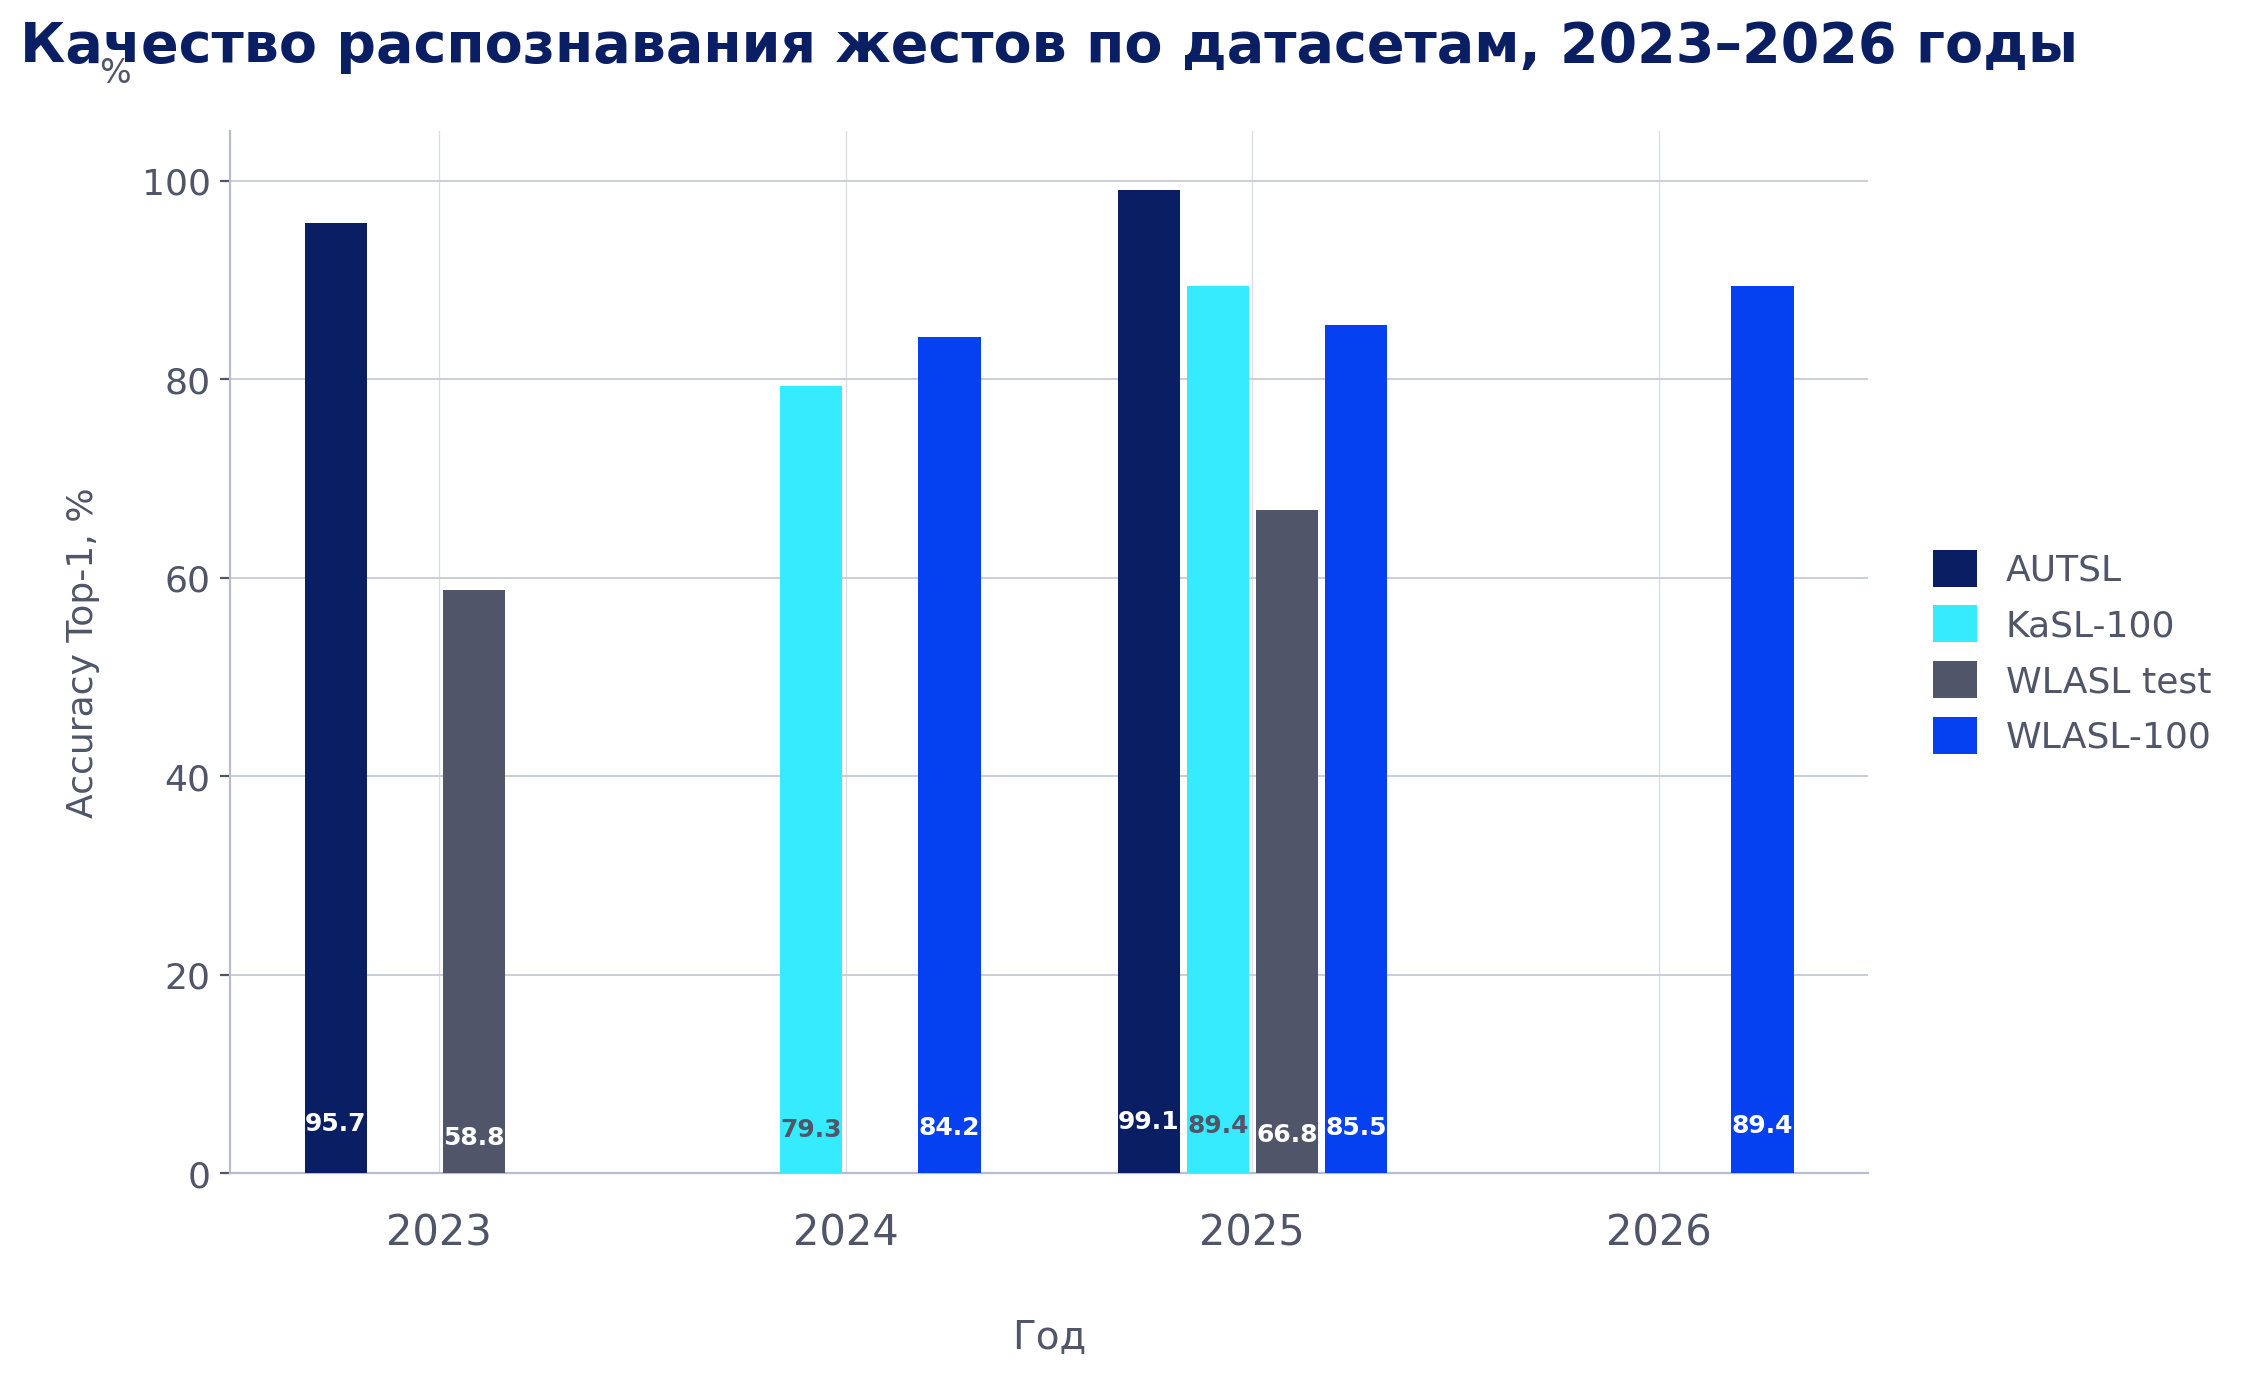

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Данные со второго графика
years = [2023, 2024, 2025, 2026]
datasets = {
    "AUTSL":      {2023: 95.7, 2025: 99.1},
    "KaSL-100":  {2024: 79.3, 2025: 89.4},
    "WLASL test":{2023: 58.8, 2025: 66.8},
    "WLASL-100": {2024: 84.2, 2025: 85.5, 2026: 89.4},
}

# Цвета из третьей картинки
colors = {
    "AUTSL": "#0a1e64",       # тёмно-синий
    "KaSL-100": "#37ebff",    # голубой
    "WLASL test": "#505569",  # тёмно-серый
    "WLASL-100": "#0541f0",   # синий
}

# Настройки
fig, ax = plt.subplots(figsize=(14, 8), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(years))
bar_width = 0.17
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]

# Столбцы
for idx, (name, vals) in enumerate(datasets.items()):
    for i, year in enumerate(years):
        if year in vals:
            value = vals[year]
            bar = ax.bar(
                x[i] + offsets[idx],
                value,
                width=bar_width * 0.9,
                color=colors[name],
                edgecolor="none",
                zorder=3
            )
            # Подпись значения внутри столбца снизу
            label_color = "white" if colors[name] in ["#0a1e64", "#0541f0", "#505569"] else "#505569"
            ax.text(
                x[i] + offsets[idx],
                max(2, value * 0.04),
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color=label_color,
                zorder=4
            )

# Оси и сетка
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("Accuracy Top-1, %", fontsize=13, color="#505569", labelpad=15)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], fontsize=15, color="#505569")
ax.tick_params(axis="y", labelsize=13, colors="#505569")
ax.tick_params(axis="x", length=0, pad=14)

# Сетка в стиле примера
ax.grid(axis="y", linestyle="-", linewidth=0.7, color="#c9ced8", zorder=0)
ax.grid(axis="x", linestyle="-", linewidth=0.45, color="#d9dde5", zorder=0)

# Убираем лишние рамки
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#b7bdca")
ax.spines["bottom"].set_color("#b7bdca")

# Заголовок
ax.set_title(
    "Качество распознавания жестов по датасетам, 2023–2026 годы",
    fontsize=20,
    fontweight="bold",
    color="#0a1e64",
    pad=25
)

# Единица измерения сверху слева как в примере
ax.text(
    -0.08, 1.04, "%",
    transform=ax.transAxes,
    fontsize=12,
    color="#505569",
    ha="left",
    va="bottom"
)

# Легенда справа
legend_items = [
    Patch(facecolor=colors[name], label=name)
    for name in datasets.keys()
]
legend = ax.legend(
    handles=legend_items,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=13,
    handlelength=1.2,
    handleheight=1.2,
    labelcolor="#505569"
)

# Подпись снизу
ax.text(
    0.5, -0.14,
    "Год",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=14,
    color="#505569"
)

plt.tight_layout(rect=[0.03, 0.06, 0.83, 0.95])


output_path


Готово: /mnt/data/gesture_quality_bar_chart.png


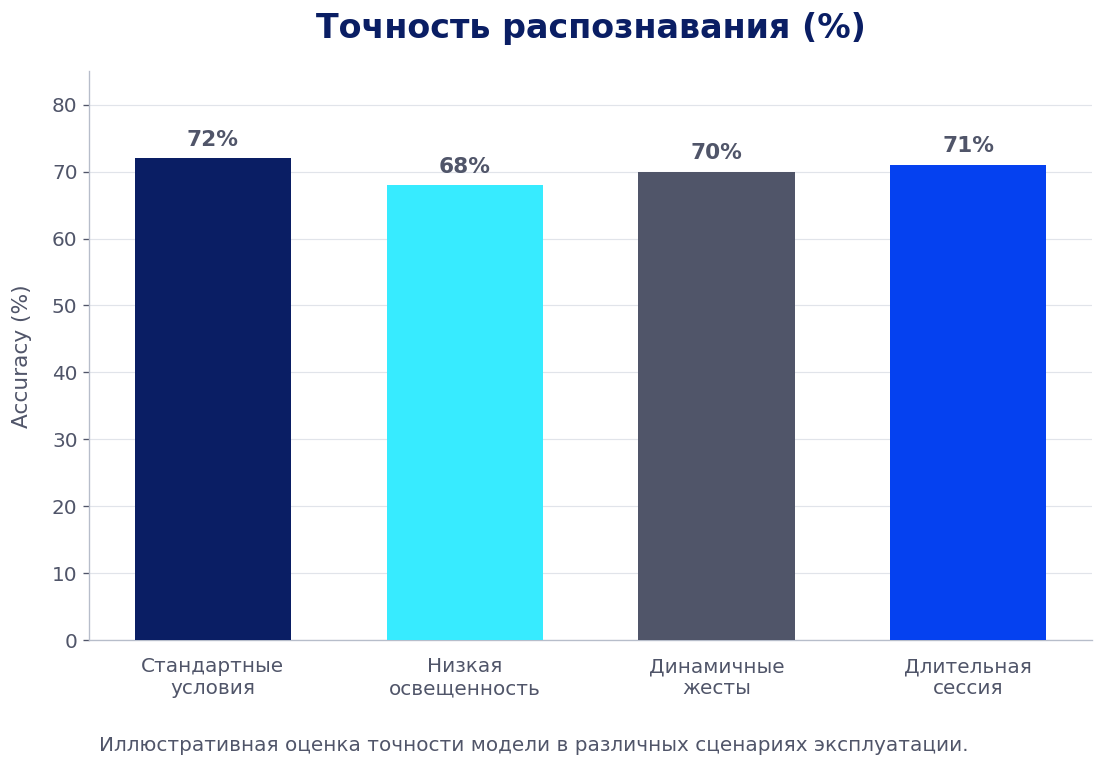

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Данные с исходного графика
categories = [
    "Стандартные\nусловия",
    "Низкая\nосвещенность",
    "Динамичные\nжесты",
    "Длительная\nсессия",
]
values = [72, 68, 70, 71]

# Цвета из фирменной палитры
palette = {
    "dark_blue": "#0a1e64",
    "cyan": "#37ebff",
    "dark_gray": "#505569",
    "blue": "#0541f0",
    "white": "#ffffff",
}

bar_colors = [
    palette["dark_blue"],
    palette["cyan"],
    palette["dark_gray"],
    palette["blue"],
]

# Создание графика
fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
fig.patch.set_facecolor(palette["white"])
ax.set_facecolor(palette["white"])

x = np.arange(len(categories))
bars = ax.bar(
    x,
    values,
    width=0.62,
    color=bar_colors,
    edgecolor="none",
    zorder=3
)

# Подписи значений над столбцами
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.3,
        f"{value}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=palette["dark_gray"]
    )

# Настройка осей
ax.set_ylim(0, 85)
ax.set_yticks(np.arange(0, 81, 10))
ax.set_ylabel(
    "Accuracy (%)",
    fontsize=13,
    color=palette["dark_gray"],
    labelpad=12
)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, color=palette["dark_gray"])
ax.tick_params(axis="y", labelsize=12, colors=palette["dark_gray"])
ax.tick_params(axis="x", length=0, pad=10)

# Сетка и рамки в стиле предыдущих графиков
ax.grid(axis="y", linestyle="-", linewidth=0.7, color="#d7dbe3", alpha=0.75, zorder=0)
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#b7bdca")
ax.spines["bottom"].set_color("#b7bdca")

# Заголовок
ax.set_title(
    "Точность распознавания (%)",
    fontsize=20,
    fontweight="bold",
    color=palette["dark_blue"],
    pad=20
)

# Подпись под графиком
fig.text(
    0.5,
    0.045,
    "Иллюстративная оценка точности модели в различных сценариях эксплуатации.",
    ha="center",
    va="center",
    fontsize=12,
    color=palette["dark_gray"]
)

plt.tight_layout(rect=[0.05, 0.08, 0.98, 0.94])

# Сохранени
print(f"Готово: {output_path}")